## **Аналіз результатів A/B тесту: Вплив знижки 50% на конверсію**

**Мета:** Оцінити зміну конверсії в оплату при впровадженні акційної пропозиції (знижка 50%) на сторінці оплати.

**Гіпотеза:** Акцент на вигоді збільшить кількість підписок.

**Період проведення тесту:** 03.07.2023 — 25.07.2023.

**Для аналізу використано 21 повний день** (з метою забезпечення рівномірного представлення всіх днів тижня та уникнення впливу неповних даних у дні запуску та зупинки тесту).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

## **1. Завантаження та перевірка даних**

In [ ]:
df = pd.read_csv('ab_test_data.csv')

print("--- Загальна інформація про датасет ---")
df.info()

print("\n--- Перші 5 рядків таблиці ---")
print(df.head())

print("\n--- Розподіл користувачів по групах ---")
group_counts = df['test_group'].value_counts()
print(group_counts)

duplicates = df.duplicated(subset=['user_id']).sum()
print(f"\nКількість дублікатів (user_id): {duplicates}")

--- Загальна інформація про датасет ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB

--- Перші 5 рядків таблиці ---
                                user_id                   timestamp  \
0  7f6833e6-1141-4f20-b4b2-f1e31019b1fd  2023-07-04 04:40:55.848109   
1  e6a6e960-d3f3-4074-a516-ba1e609b211e  2023-07-06 00:26:45.486187   
2  4d3fbfa5-6847-410a-bac2-477f01d5f400  2023-07-10 20:24:33.639464   
3  361457d9-a044-48f7-981c-d67dc3861679  2023-07-20 07:04:49.957013   
4  285cd63d-7d03-427f-a062-1fa2dd2e77d6  2023-07-19 23:27:50.116680   

  test_group  conversion  
0          a           0  
1          b           0  
2          b        

In [ ]:
n_a = df[df['test_group'] == 'a'].shape[0]
n_b = df[df['test_group'] == 'b'].shape[0]

print(f"Кількість користувачів у групі A (Контроль): {n_a}")
print(f"Кількість користувачів у групі B (Тест): {n_b}")

Кількість користувачів у групі A (Контроль): 10013
Кількість користувачів у групі B (Тест): 9985


## **2. Розрахунок основних метрик**

In [ ]:
conv_a = df[df['test_group'] == 'a']['conversion'].sum()
conv_b = df[df['test_group'] == 'b']['conversion'].sum()

print(f"Кількість конверсій у групі A: {conv_a}")
print(f"Кількість конверсій у групі B: {conv_b}")

Кількість конверсій у групі A: 611
Кількість конверсій у групі B: 889


In [ ]:
cr_a = conv_a / n_a
cr_b = conv_b / n_b

print(f"Рівень конверсії у групі A: {cr_a:.2%}")
print(f"Рівень конверсії у групі B: {cr_b:.2%}")

lift = (cr_b - cr_a) / cr_a
print(f"\nВідносний приріст конверсії (Lift): {lift:.2%}")

Рівень конверсії у групі A: 6.10%
Рівень конверсії у групі B: 8.90%

Відносний приріст конверсії (Lift): 45.91%


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

start_date = df['timestamp'].min()
end_date = df['timestamp'].max()

duration = end_date - start_date

print(f"Дата початку тесту: {start_date}")
print(f"Дата кінця тесту: {end_date}")
print(f"Загальна тривалість тесту: {duration.days} днів")

Дата початку тесту: 2023-07-03 01:42:34.033708
Дата кінця тесту: 2023-07-25 01:41:19.152664
Загальна тривалість тесту: 21 днів


## **3. Статистична перевірка (Хі-квадрат)**

In [ ]:
table = [
    [611, 10013 - 611],
    [889, 9985 - 889]
    ]

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print(f"Обраний критерій: Хі-квадрат (Chi-square test)")
print(f"Статистика Хі-квадрат: {chi2:.4f}")
print(f"p-value: {p_value:.10e}")

alpha = 0.05
if p_value < alpha:
    print(f"\nВисновок: Оскільки p-value ({p_value:.10e}) < {alpha}, ми ВІДХИЛЯЄМО нульову гіпотезу.")
    print("Різниця між групами є статистично значущою.")
else:
    print(f"\nВисновок: Оскільки p-value ({p_value:.10e}) >= {alpha}, ми НЕ МОЖЕМО відхилити нульову гіпотезу.")
    print("Різниця між групами може бути випадковою.")

Обраний критерій: Хі-квадрат (Chi-square test)
Статистика Хі-квадрат: 56.1425
p-value: 6.7404407305e-14

Висновок: Оскільки p-value (6.7404407305e-14) < 0.05, ми ВІДХИЛЯЄМО нульову гіпотезу.
Різниця між групами є статистично значущою.


## **4. Візуалізація результатів**

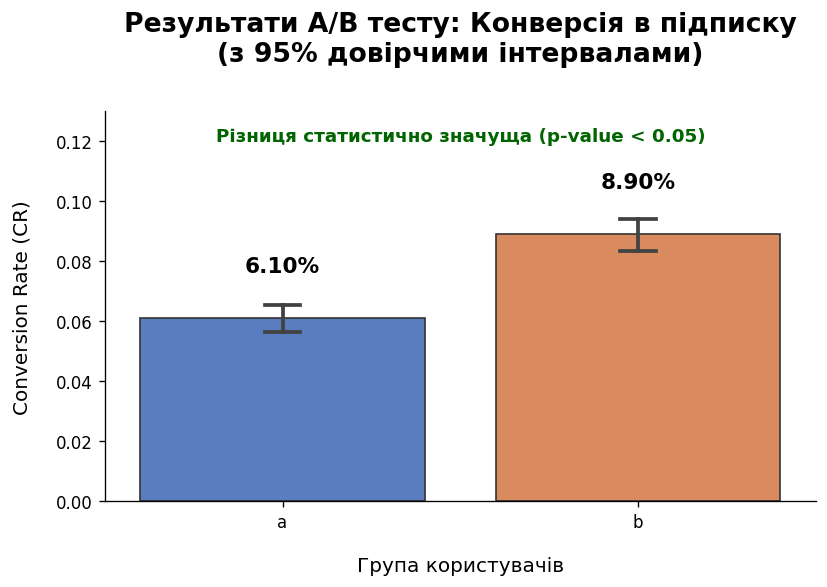

In [ ]:
plt.figure(figsize=(7, 5), dpi=120)

ax = sns.barplot(
    x='test_group',
    y='conversion',
    data=df,
    hue='test_group',
    capsize=.1,
    palette='muted',
    edgecolor="0.2",
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2%}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        xytext=(0, 25),
        textcoords='offset points',
        fontsize=13,
        fontweight='bold'
    )

plt.title('Результати A/B тесту: Конверсія в підписку\n(з 95% довірчими інтервалами)', fontsize=16, pad=30, fontweight='bold')
plt.xlabel('Група користувачів', fontsize=12, labelpad=15)
plt.ylabel('Conversion Rate (CR)', fontsize=12, labelpad=15)

plt.ylim(0, 0.13)

plt.text(0.5, 0.12, "Різниця статистично значуща (p-value < 0.05)",
         ha='center', fontsize=11, color='darkgreen', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

sns.despine()
plt.tight_layout()
plt.show()

## **Бонусне завдання: Аналіз стабілізації конверсії**

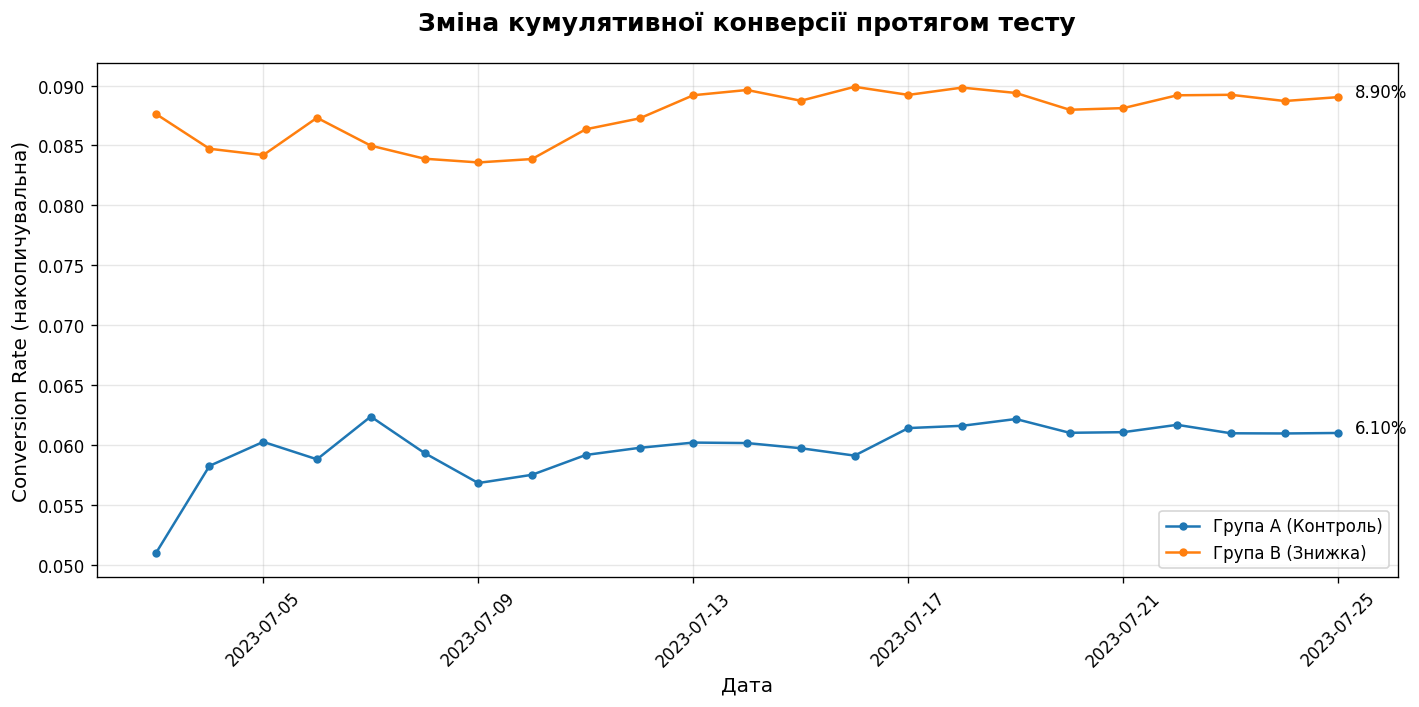

In [ ]:
df['date'] = df['timestamp'].dt.date
group_a = df[df['test_group'] == 'a']
group_b = df[df['test_group'] == 'b']

cumulative_a = group_a.groupby('date')['conversion'].agg(['sum', 'count']).cumsum()
cumulative_a['conversion_rate'] = cumulative_a['sum'] / cumulative_a['count']

cumulative_b = group_b.groupby('date')['conversion'].agg(['sum', 'count']).cumsum()
cumulative_b['conversion_rate'] = cumulative_b['sum'] / cumulative_b['count']

plt.figure(figsize=(12, 6), dpi=120)

plt.plot(cumulative_a.index, cumulative_a['conversion_rate'], label='Група A (Контроль)', marker='o', markersize=4)
plt.plot(cumulative_b.index, cumulative_b['conversion_rate'], label='Група B (Знижка)', marker='o', markersize=4)

plt.title('Зміна кумулятивної конверсії протягом тесту', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Conversion Rate (накопичувальна)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)

plt.annotate(f"{cumulative_a['conversion_rate'].iloc[-1]:.2%}",
             xy=(cumulative_a.index[-1], cumulative_a['conversion_rate'].iloc[-1]), xytext=(10, 0), textcoords='offset points')
plt.annotate(f"{cumulative_b['conversion_rate'].iloc[-1]:.2%}",
             xy=(cumulative_b.index[-1], cumulative_b['conversion_rate'].iloc[-1]), xytext=(10, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

**Аналіз динаміки кумулятивної конверсії**

**Стабілізація метрики:** На графіку чітко видно, що після першого тижня тестування (приблизно з 10-12 липня) коливання обох ліній зменшилися, і показники конверсії стабілізувалися. Це свідчить про те, що ми набрали достатньо даних для отримання достовірного результату.

**Відсутність перетинів:** Протягом усього періоду тестування лінія групи B (знижка) стабільно знаходиться вище лінії групи A (контроль). Жодного перетину ліній не зафіксовано, що є візуальним підтвердженням переваги тестового варіанту.

**Відрив між групами:** Починаючи з 13 липня, розрив між групами став фіксованим і практично не змінювався до кінця тесту. Це доводить, що позитивний ефект від пропозиції знижки є стійким у часі, а не випадковим сплеском.

**Фінальні значення:** На момент завершення тесту (25 липня) кумулятивна конверсія групи B зафіксувалася на рівні 8.90%, тоді як у групи A вона склала 6.10%.

## **Загальний висновок та бізнес-рекомендації**

### **1. Параметри тесту та чистота даних**

**Загальна кількість унікальних користувачів:** **19,998 осіб** (після перевірки на дублікати, які відсутні).

**Розподіл по групах:** Група **A** (Контроль) — **10,013** осіб; Група **B** (Тест) — **9,985** осіб.

**Дати проведення тесту:** з **03.07.2023** по **25.07.2023**.

**Тривалість:** **21** повний день.

### **2. Ключові метрики та ефективність**

**Конверсія (CR):** Впровадження знижки 50% у варіанті **B** призвело до зростання конверсії з **6.10%** до **8.90%**.

**Відносний приріст (Lift):** Варіант **B** ефективніший за варіант **A** на **45.91%**.

### **3. Статистична значущість**

Для перевірки використано критерій **Хі-квадрат** (χ
2
 =56.14).

Значення **p-value<0.001** (6.74×10
−14
 ), що значно менше α=0.05.

**Висновок:** Результати статистично значущі, нульова гіпотеза відхиляється.

### **4. Аналіз стабільності (Бонусне завдання)**

Кумулятивні метрики стабілізувалися після 10-го дня тесту, що підтверджує надійність даних.

Відсутність перетинів графіків доводить стійку перевагу тестового варіанта.

### **Остаточне рішення:**
Враховуючи статистичне підтвердження та стабільну позитивну динаміку варіанта **В**, **рекомендую впровадити оновлений дизайн зі знижкою 50%** на 100% користувачів. Це дозволить суттєво підвищити загальну кількість оплат та дохід компанії.